# Descriptive Analytics: Cereal Production Statistics (Maha Season 2007)

**Dataset:** Cereal production statistics from data.gov.lk (Sri Lanka)  
**Objective:** Apply data preprocessing, summary statistics, distribution analysis, and visualization.

## 1. Setup and Data Loading

In [2]:
# Install/import libraries (run in Colab)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# In Google Colab: uncomment and run to upload your CSV, then run the next line
# from google.colab import files
# uploaded = files.upload()  # choose: cereal_production_statistics_maha_season_2007.csv

# Load dataset (use same filename after upload, or set path to your file)
csv_path = 'cereal_production_statistics_maha_season_2007.csv'
df = pd.read_csv(csv_path)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Display first few rows
df.head(10)

,DISTRICT,KURAKKAN AREA Hect.,KURAKKAN PROD. M.T.,MAIZE AREA Hect.,MAIZE PROD M.T.,SORGHUM AREA Hect.,SORGHUM PROD M.T.,MENERI AREA Hect.,MENERI PROD M.T.,GREEN GRAM AREA Hect.,...,LEEKS AREA Hect.,LEEKS PROD M.T.,ASH PUMPKIN AREA Hect.,ASH PUMPKIN PROD M.T.,RED PUMPKIN AREA Hect.,RED PUMPKIN PROD M.T.,ASH PLANTAIN AREA Hect.,ASH PLANTAIN PROD M.T.,CAPSICUM AREA Hect.,CAPSICUM PROD M.T.
0,COLOMBO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,38.0,32,362,5,22
1,GAMPAHA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,52.0,92,742,26,80
2,KALUTARA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,12.0,NaN,NaN,59,397,15,52
3,KANDY,144.0,242.0,277.0,497.0,20.0,32.0,NaN,NaN,20.0,...,39.0,425.0,4.0,40.0,66.0,956.0,95,1065,80,319
4,MATALE,133.0,181.0,257.0,259.0,2.0,1.0,NaN,NaN,27.0,...,12.0,35.0,7.0,62.0,116.0,1749.0,139,1284,80,261
5,NUWARA ELIYA,164.0,87.0,203.0,140.0,NaN,NaN,NaN,NaN,7.0,...,736.0,10729.0,1.0,11.0,87.0,1515.0,52,273,436,1884
6,GALLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,24.0,175,1286,32,140
7,MATARA,4.0,3.0,1.0,2.0,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,1.0,5.0,10.0,44.0,139,762,15,82
8,HAMBANTOTA,531.0,640.0,507.0,618.0,20.0,17.0,17.0,11.0,1266.0,...,NaN,NaN,61.0,756.0,314.0,4377.0,336,3991,18,91
9,JAFFNA,65.0,44.0,7.0,4.0,NaN,NaN,9.0,12.0,92.0,...,32.0,154.0,39.0,319.0,103.0,798.0,98,1004,20,78


## 2. Data Preprocessing

In [3]:
# Inspect structure
print("Shape:", df.shape)
print("\nColumn names (first 15):", list(df.columns[:15]))
print("\nData types:")
df.dtypes.head(20)

Shape: (27, 81)

Column names (first 15): ['DISTRICT', 'KURAKKAN AREA Hect.', 'KURAKKAN PROD. M.T.', 'MAIZE AREA Hect.', 'MAIZE PROD   M.T.', 'SORGHUM AREA Hect.', 'SORGHUM PROD   M.T.', 'MENERI AREA Hect.', 'MENERI PROD   M.T.', 'GREEN GRAM AREA Hect.', 'GREEN GRAM PROD   M.T.', 'COWPEA AREA Hect.', 'COWPEA PROD   M.T.', 'SOYA BEANS AREA Hect.', 'SOYA BEANS PROD   M.T.']

Data types:


DISTRICT                   object
KURAKKAN AREA Hect.       float64
KURAKKAN PROD. M.T.       float64
MAIZE AREA Hect.          float64
MAIZE PROD   M.T.         float64
SORGHUM AREA Hect.        float64
SORGHUM PROD   M.T.       float64
MENERI AREA Hect.         float64
MENERI PROD   M.T.        float64
GREEN GRAM AREA Hect.     float64
GREEN GRAM PROD   M.T.    float64
COWPEA AREA Hect.         float64
COWPEA PROD   M.T.        float64
SOYA BEANS AREA Hect.     float64
SOYA BEANS PROD   M.T.    float64
BLACK GRAM AREA Hect.     float64
BLACK GRAM PROD   M.T.    float64
DHALL AREA Hect.          float64
DHALL PROD   M.T.         float64
GINGELLY AREA Hect.       float64
dtype: object

In [4]:
# Clean DISTRICT column (strip spaces)
df['DISTRICT'] = df['DISTRICT'].astype(str).str.strip()

# Exclude aggregate row 'SRI LANKA' for district-level analysis
df_districts = df[df['DISTRICT'] != 'SRI LANKA'].copy()

# Identify numeric columns (exclude DISTRICT)
numeric_cols = [c for c in df_districts.columns if c != 'DISTRICT']

# Convert numeric columns: replace empty strings and coerce to float
for col in numeric_cols:
    df_districts[col] = pd.to_numeric(df_districts[col], errors='coerce')

print("Preprocessed shape (districts only):", df_districts.shape)
df_districts.head()

Preprocessed shape (districts only): (26, 81)


,DISTRICT,KURAKKAN AREA Hect.,KURAKKAN PROD. M.T.,MAIZE AREA Hect.,MAIZE PROD M.T.,SORGHUM AREA Hect.,SORGHUM PROD M.T.,MENERI AREA Hect.,MENERI PROD M.T.,GREEN GRAM AREA Hect.,...,LEEKS AREA Hect.,LEEKS PROD M.T.,ASH PUMPKIN AREA Hect.,ASH PUMPKIN PROD M.T.,RED PUMPKIN AREA Hect.,RED PUMPKIN PROD M.T.,ASH PLANTAIN AREA Hect.,ASH PLANTAIN PROD M.T.,CAPSICUM AREA Hect.,CAPSICUM PROD M.T.
0,COLOMBO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,38.0,32,362,5,22
1,GAMPAHA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,52.0,92,742,26,80
2,KALUTARA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,12.0,NaN,NaN,59,397,15,52
3,KANDY,144.0,242.0,277.0,497.0,20.0,32.0,NaN,NaN,20.0,...,39.0,425.0,4.0,40.0,66.0,956.0,95,1065,80,319
4,MATALE,133.0,181.0,257.0,259.0,2.0,1.0,NaN,NaN,27.0,...,12.0,35.0,7.0,62.0,116.0,1749.0,139,1284,80,261


In [5]:
# Create crop-level summary: extract production columns (M.T.) for key crops
# Columns with 'PROD' and 'M.T' in name are production in metric tons
prod_cols = [c for c in df_districts.columns if 'PROD' in c.upper() and 'M.T' in c.upper()]
area_cols = [c for c in df_districts.columns if 'AREA' in c.upper() and 'Hect' in c.upper()]

print("Number of production columns:", len(prod_cols))
print("Number of area columns:", len(area_cols))

Number of production columns: 40
Number of area columns: 0


## 3. Summary Statistics

In [6]:
# Overall summary statistics for all numeric columns
summary = df_districts[numeric_cols].describe()
summary

,KURAKKAN AREA Hect.,KURAKKAN PROD. M.T.,MAIZE AREA Hect.,MAIZE PROD M.T.,SORGHUM AREA Hect.,SORGHUM PROD M.T.,MENERI AREA Hect.,MENERI PROD M.T.,GREEN GRAM AREA Hect.,GREEN GRAM PROD M.T.,...,LEEKS AREA Hect.,LEEKS PROD M.T.,ASH PUMPKIN AREA Hect.,ASH PUMPKIN PROD M.T.,RED PUMPKIN AREA Hect.,RED PUMPKIN PROD M.T.,ASH PLANTAIN AREA Hect.,ASH PLANTAIN PROD M.T.,CAPSICUM AREA Hect.,CAPSICUM PROD M.T.
count,21.000000,21.000000,22.000000,22.000000,9.000000,9.000000,5.000000,5.000000,22.000000,22.000000,...,9.000000,9.000000,23.000000,23.000000,25.000000,25.000000,26.000000,26.000000,26.000000,26.000000
mean,205.047619,217.428571,1231.590909,2048.545455,10.666667,12.333333,9.200000,6.600000,276.954545,265.727273,...,104.333333,1418.555556,22.521739,208.695652,163.880000,1804.680000,185.038462,1500.961538,66.269231,317.038462
std,294.239949,314.078107,2543.649528,4765.814623,7.968689,10.931606,6.180615,4.827007,421.152215,428.233824,...,239.582971,3518.314089,28.426731,291.956011,258.547275,2860.818206,172.858898,1850.173710,100.657263,553.476755
min,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,...,1.000000,5.000000,1.000000,5.000000,3.000000,24.000000,19.000000,127.000000,2.000000,13.000000
25%,19.000000,19.000000,87.750000,63.750000,5.000000,3.000000,6.000000,3.000000,21.750000,34.750000,...,2.000000,32.000000,2.500000,21.500000,10.000000,66.000000,88.250000,446.500000,15.000000,60.750000
50%,118.000000,106.000000,219.000000,257.500000,8.000000,12.000000,9.000000,6.000000,121.000000,127.500000,...,12.000000,35.000000,9.000000,62.000000,76.000000,956.000000,109.500000,1054.000000,28.500000,100.000000
75%,194.000000,242.000000,521.250000,630.000000,18.000000,20.000000,13.000000,11.000000,237.000000,242.250000,...,39.000000,425.000000,30.000000,289.500000,172.000000,2262.000000,238.750000,1464.750000,63.500000,247.500000
max,1177.000000,1106.000000,10276.000000,20275.000000,20.000000,32.000000,17.000000,12.000000,1514.000000,1757.000000,...,736.000000,10729.000000,100.000000,1125.000000,1192.000000,12258.000000,731.000000,9256.000000,436.000000,2114.000000


In [7]:
# Summary for production columns only
prod_summary = df_districts[prod_cols].describe()
print("Summary statistics - Production (M.T.) columns:")
prod_summary

Summary statistics - Production (M.T.) columns:


,KURAKKAN PROD. M.T.,MAIZE PROD M.T.,SORGHUM PROD M.T.,MENERI PROD M.T.,GREEN GRAM PROD M.T.,COWPEA PROD M.T.,SOYA BEANS PROD M.T.,BLACK GRAM PROD M.T.,DHALL PROD M.T.,GINGELLY PROD M.T.,...,CARROT PROD M.T.,KNOLKHOL PROD M.T.,BEETROOT PROD M.T.,RADDISH PROD M.T.,BEANS PROD M.T.,LEEKS PROD M.T.,ASH PUMPKIN PROD M.T.,RED PUMPKIN PROD M.T.,ASH PLANTAIN PROD M.T.,CAPSICUM PROD M.T.
count,21.000000,22.000000,9.000000,5.000000,22.000000,22.000000,11.000000,19.000000,1.0,20.0000,...,11.000000,12.000000,15.000000,22.000000,17.0000,9.000000,23.000000,25.000000,26.000000,26.000000
mean,217.428571,2048.545455,12.333333,6.600000,265.727273,304.727273,44.181818,327.263158,3.0,114.5505,...,1762.272727,592.666667,872.266667,726.272727,1440.0000,1418.555556,208.695652,1804.680000,1500.961538,317.038462
std,314.078107,4765.814623,10.931606,4.827007,428.233824,470.486089,93.053553,872.336635,NaN,165.6389,...,3927.759033,1146.538215,1737.713870,1437.476797,3276.5697,3518.314089,291.956011,2860.818206,1850.173710,553.476755
min,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,0.0100,...,8.000000,3.000000,14.000000,9.000000,2.0000,5.000000,5.000000,24.000000,127.000000,13.000000
25%,19.000000,63.750000,3.000000,3.000000,34.750000,25.250000,1.500000,3.500000,3.0,7.2500,...,40.500000,11.000000,55.500000,51.500000,30.0000,32.000000,21.500000,66.000000,446.500000,60.750000
50%,106.000000,257.500000,12.000000,6.000000,127.500000,129.000000,2.000000,15.000000,3.0,19.0000,...,66.000000,63.000000,221.000000,139.500000,137.0000,35.000000,62.000000,956.000000,1054.000000,100.000000
75%,242.000000,630.000000,20.000000,11.000000,242.250000,286.750000,11.000000,42.000000,3.0,157.7500,...,659.500000,320.750000,858.500000,595.000000,1584.0000,425.000000,289.500000,2262.000000,1464.750000,247.500000
max,1106.000000,20275.000000,32.000000,12.000000,1757.000000,1695.000000,282.000000,3608.000000,3.0,479.0000,...,12756.000000,3128.000000,6781.000000,5025.000000,13352.0000,10729.000000,1125.000000,12258.000000,9256.000000,2114.000000


In [8]:
# Key metrics: total production by crop (sum across districts)
total_prod = df_districts[prod_cols].sum()
total_prod_sorted = total_prod.sort_values(ascending=False)
print("Total production (M.T.) by crop (top 15):")
print(total_prod_sorted.head(15).to_string())

Total production (M.T.) by crop (top 15):
MANIOC PROD   M.T.              126209.0
BRINJALS PROD   M.T.             54851.0
RED PUMPKIN PROD   M.T.          45117.0
MAIZE PROD   M.T.                45068.0
CABBAGE PROD   M.T.              40653.0
ASH PLANTAIN PROD   M.T.         39025.0
TOMATOES PROD   M.T.             37793.0
CHILLIES (GREEN) PROD   M.T.     31752.0
POTATOES PROD   M.T.             31481.0
RED ONIONS PROD   M.T.           27881.0
BANDAKKA PROD   M.T.             25146.0
BEANS PROD   M.T.                24480.0
SWEET POTATOES PROD   M.T.       21891.0
BITTER GOURD PROD   M.T.         19750.0
CARROT PROD   M.T.               19385.0


In [9]:
# Missing values summary
missing = df_districts[numeric_cols].isna().sum()
missing_pct = (missing / len(df_districts) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print("Missing values (columns with any missing):")
missing_df[missing_df['Missing'] > 0].head(20)

Missing values (columns with any missing):


,Missing,Percent
KURAKKAN AREA Hect.,5,19.2
KURAKKAN PROD. M.T.,5,19.2
MAIZE AREA Hect.,4,15.4
MAIZE PROD M.T.,4,15.4
SORGHUM AREA Hect.,17,65.4
SORGHUM PROD M.T.,17,65.4
MENERI AREA Hect.,21,80.8
MENERI PROD M.T.,21,80.8
GREEN GRAM AREA Hect.,4,15.4
GREEN GRAM PROD M.T.,4,15.4


## 4. Distribution Analysis

In [10]:
# Distribution of a few key production variables
key_prod = [c for c in prod_cols if 'MAIZE' in c or 'POTATOES' in c or 'MANIOC' in c or 'RED ONIONS' in c][:4]
if not key_prod:
    key_prod = prod_cols[:4]

print("Distribution stats for selected production columns:")
df_districts[key_prod].describe()

Distribution stats for selected production columns:


,MAIZE PROD M.T.,MANIOC PROD M.T.,SWEET POTATOES PROD M.T.,POTATOES PROD M.T.
count,22.000000,26.000000,26.000000,8.000000
mean,2048.545455,4854.192308,841.961538,3935.125000
std,4765.814623,3756.820209,902.935589,9779.976051
min,2.000000,167.000000,28.000000,2.000000
25%,63.750000,2186.750000,206.000000,8.750000
50%,257.500000,3955.500000,671.000000,29.500000
75%,630.000000,5616.250000,896.750000,882.250000
max,20275.000000,14324.000000,3859.000000,27962.000000


In [11]:
# Skewness and kurtosis (distribution shape)
dist_stats = pd.DataFrame({
    'mean': df_districts[prod_cols].mean(),
    'std': df_districts[prod_cols].std(),
    'skewness': df_districts[prod_cols].skew(),
    'kurtosis': df_districts[prod_cols].kurtosis()
})
print("Distribution shape (skewness & kurtosis) for production columns:")
dist_stats.head(15)

Distribution shape (skewness & kurtosis) for production columns:


,mean,std,skewness,kurtosis
KURAKKAN PROD. M.T.,217.428571,314.078107,2.047285,3.504628
MAIZE PROD M.T.,2048.545455,4765.814623,3.171952,10.681695
SORGHUM PROD M.T.,12.333333,10.931606,0.554444,-0.734186
MENERI PROD M.T.,6.600000,4.827007,0.074687,-2.527768
GREEN GRAM PROD M.T.,265.727273,428.233824,2.678713,7.374133
COWPEA PROD M.T.,304.727273,470.486089,2.220074,4.230862
SOYA BEANS PROD M.T.,44.181818,93.053553,2.236719,4.290476
BLACK GRAM PROD M.T.,327.263158,872.336635,3.386139,12.155491
DHALL PROD M.T.,3.000000,NaN,NaN,NaN
GINGELLY PROD M.T.,114.550500,165.638900,1.434585,0.648813


## 5. Data Visualization

### 5.1 Histograms (distribution of production values)

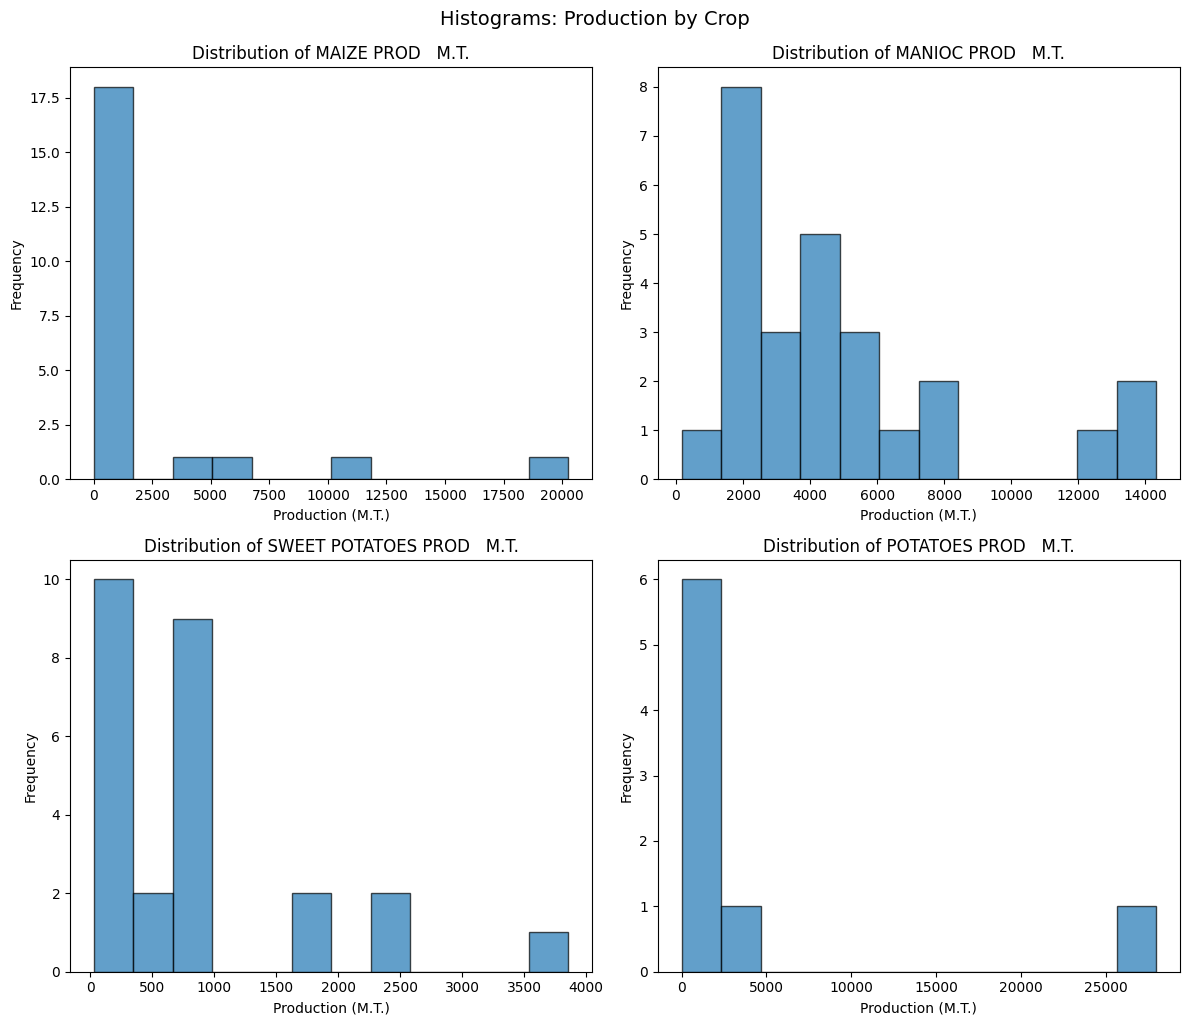

In [12]:
# Histograms for selected production columns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(key_prod):
    axes[i].hist(df_districts[col].dropna(), bins=12, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col[:35]}...' if len(col) > 35 else f'Distribution of {col}')
    axes[i].set_xlabel('Production (M.T.)')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Histograms: Production by Crop', y=1.02, fontsize=14)
plt.show()

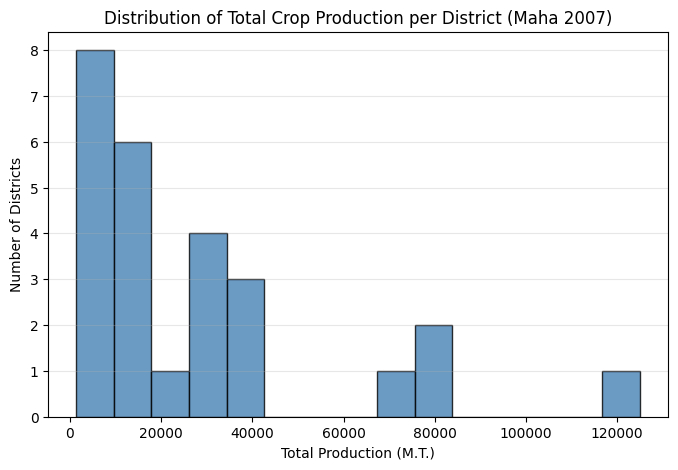

In [13]:
# Single histogram: total production per district (sum of all crops)
df_districts['Total_Production'] = df_districts[prod_cols].sum(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(df_districts['Total_Production'].dropna(), bins=15, edgecolor='black', color='steelblue', alpha=0.8)
plt.xlabel('Total Production (M.T.)')
plt.ylabel('Number of Districts')
plt.title('Distribution of Total Crop Production per District (Maha 2007)')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 5.2 Bar Charts

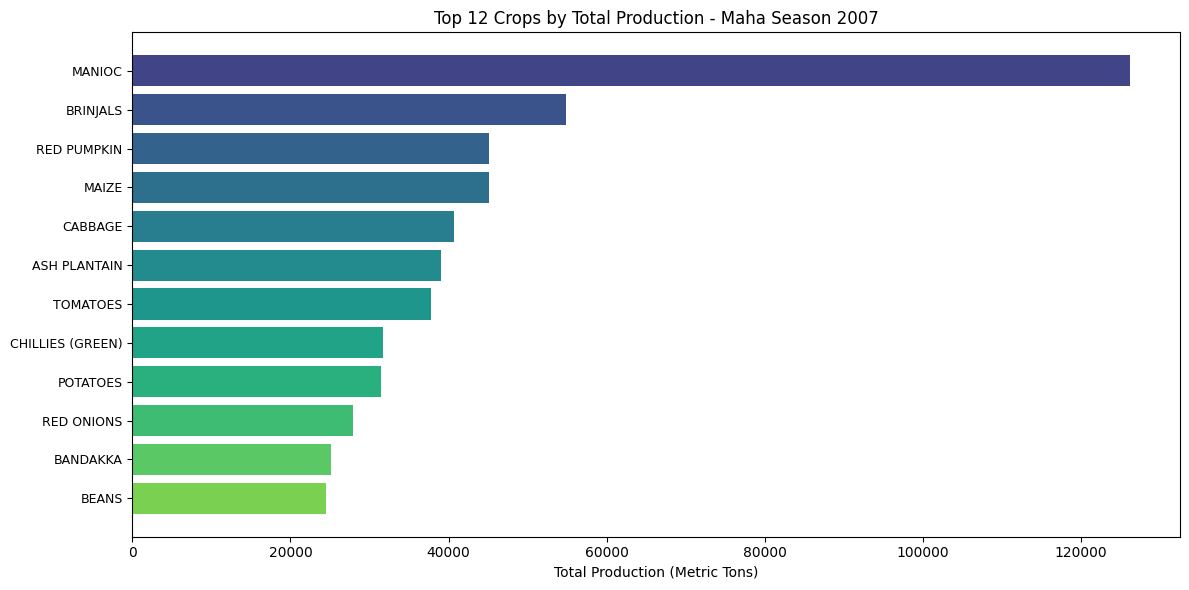

In [14]:
# Bar chart: Total production by crop (top 12 crops)
top_crops = total_prod_sorted.head(12)
labels = [c.replace(' PROD   M.T.', '').replace(' PROD. M.T.', '').strip()[:25] for c in top_crops.index]

plt.figure(figsize=(12, 6))
plt.barh(range(len(labels)), top_crops.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(labels))))
plt.yticks(range(len(labels)), labels, fontsize=9)
plt.xlabel('Total Production (Metric Tons)')
plt.title('Top 12 Crops by Total Production - Maha Season 2007')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

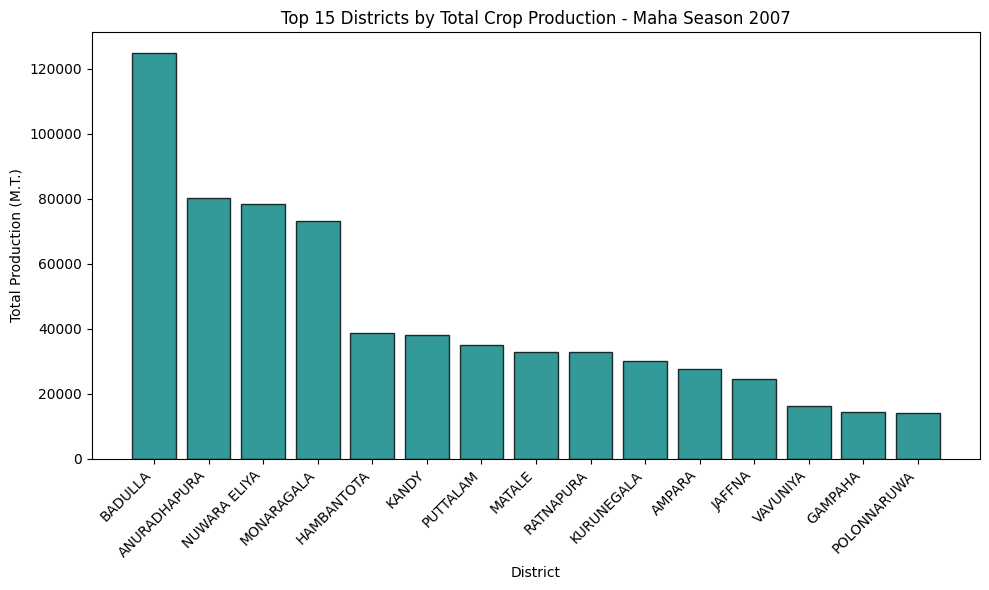

In [15]:
# Bar chart: Total production by district (top 15 districts)
district_totals = df_districts.groupby('DISTRICT')['Total_Production'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.bar(district_totals.index, district_totals.values, color='teal', alpha=0.8, edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('District')
plt.ylabel('Total Production (M.T.)')
plt.title('Top 15 Districts by Total Crop Production - Maha Season 2007')
plt.tight_layout()
plt.show()

### 5.3 Pie Charts

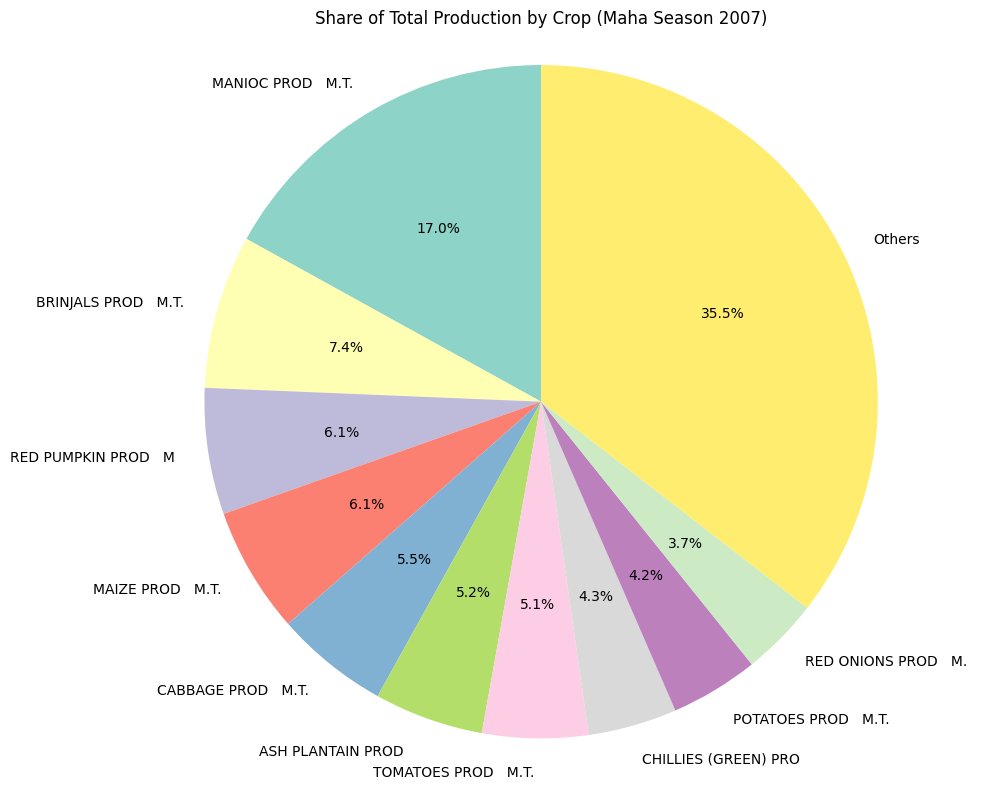

In [16]:
# Pie chart: Share of total production by crop (top 10 crops)
top10 = total_prod_sorted.head(10)
other = total_prod_sorted[10:].sum()
pie_values = list(top10.values)
pie_labels = [c.split(' AREA')[0].strip()[:20] for c in top10.index]
if other > 0:
    pie_values.append(other)
    pie_labels.append('Others')

plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(pie_labels)))
plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Share of Total Production by Crop (Maha Season 2007)')
plt.axis('equal')
plt.tight_layout()
plt.show()

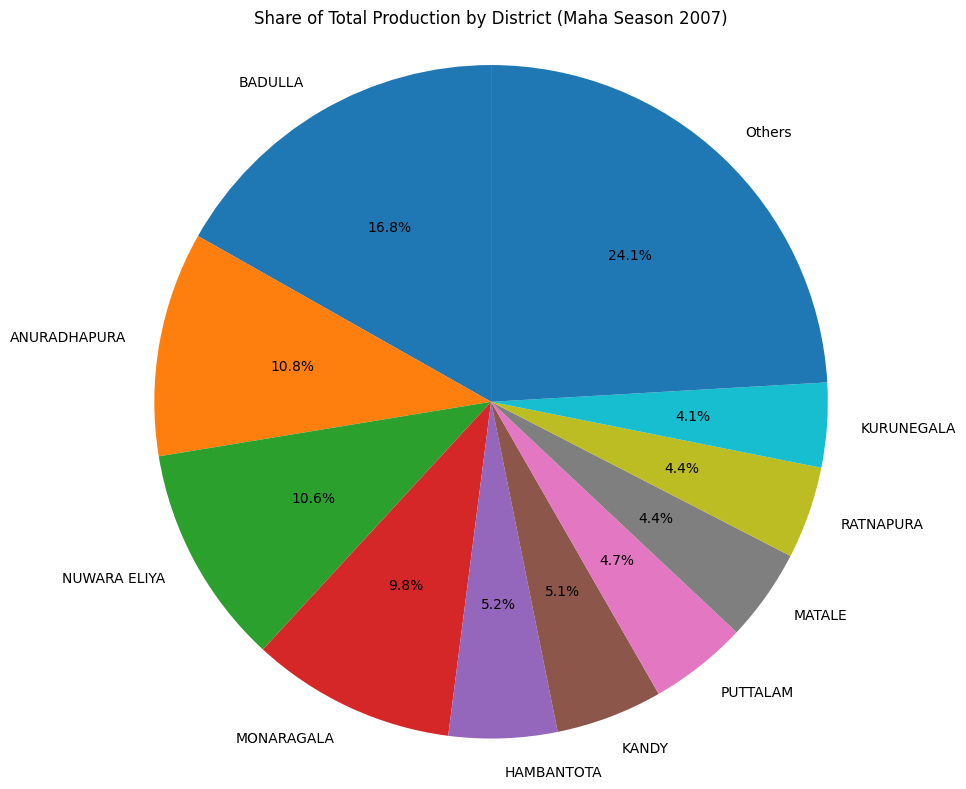

In [17]:
# Pie chart: Share of production by district (top 10 districts)
district_share = df_districts.set_index('DISTRICT')['Total_Production'].sort_values(ascending=False)
top10_dist = district_share.head(10)
other_dist = district_share[10:].sum()
d_vals = list(top10_dist.values)
d_labs = list(top10_dist.index)
if other_dist > 0:
    d_vals.append(other_dist)
    d_labs.append('Others')

plt.figure(figsize=(9, 8))
plt.pie(d_vals, labels=d_labs, autopct='%1.1f%%', startangle=90)
plt.title('Share of Total Production by District (Maha Season 2007)')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 6. Summary of Findings

- **Summary statistics** describe central tendency (mean, median) and spread (std, min, max) of area and production by crop and district.
- **Distribution analysis** shows that production values are right-skewed (many districts with low production, few with high).
- **Histograms** show the frequency distribution of production; total production per district is concentrated in a few high-producing districts.
- **Bar charts** highlight top crops (e.g. potatoes, manioc, red onions) and top districts (e.g. Badulla, Nuwara Eliya, Anuradhapura) by total production.
- **Pie charts** show the proportional share of production by crop and by district, useful for comparing relative contribution.